# Лабораторная работа №3

- Возьмите один простой набор данных (MNIST, FMNIST, CIFAR-10 и т.д.). Обучите на нём простую модель нейронной сети (не CNN!!!) с применением методов регуляризации и с функцией активации ReLU. Архитектуру задаете сами. Постройте график значения функции потерь от количества эпох, а также график метрик качества от количества эпох
- Уберите из архитектуры регуляризацию. Что стало с результатом? Постройте графики и сравните с оригинальной моделью
- Замените ReLU на сигмоиду. Что стало с результатом? Если он ухудшился, то почему? Постройте графики и сравните с оригинальной моделью
- Обучите простую CNN на выбранном датасете. Визуализируйте активации на первых слоях сети. Какие закономерности находит модель?


# Выполнение лабораторной 

In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

## Необходимые модули

#### Подготовка данных

In [40]:
def get_dataloaders(batch_size=64):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    
    full_train = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
    test_set = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
    
    train_size = int(0.9 * len(full_train))
    val_size = len(full_train) - train_size
    train_set, val_set = random_split(full_train, [train_size, val_size])
    
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader

#### Модули моделей

MLP модель

In [41]:
class FlexibleMLP(nn.Module):
    def __init__(self, activation_type='relu', use_dropout=True):
        super(FlexibleMLP, self).__init__()
        self.flatten = nn.Flatten()
        
        # Выбор функции активации
        act = nn.ReLU() if activation_type == 'relu' else nn.Sigmoid()
        
        layers = [
            nn.Linear(784, 512),
            nn.BatchNorm1d(512) if use_dropout else nn.Identity(),
            act,
            nn.Dropout(0.3) if use_dropout else nn.Identity(),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256) if use_dropout else nn.Identity(),
            act,
            nn.Dropout(0.3) if use_dropout else nn.Identity(),
            
            nn.Linear(256, 10)
        ]
        self.model = nn.Sequential(*[l for l in layers if not isinstance(l, nn.Identity)])

    def forward(self, x):
        x = self.flatten(x)
        return self.model(x)

CNN модель

In [42]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.fc = nn.Linear(64 * 7 * 7, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        return self.fc(x)

#### Модуль обучения и валидации

In [43]:
class Trainer:
    def __init__(self, model, lr=0.001):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = model.to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.criterion = nn.CrossEntropyLoss()
        
        self.history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    def train_epoch(self, loader):
        self.model.train()
        running_loss, correct = 0.0, 0
        for images, labels in loader:
            images, labels = images.to(self.device), labels.to(self.device)
            
            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.criterion(outputs, labels)
            loss.backward()
            self.optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()
            
        return running_loss / len(loader), correct / len(loader.dataset)

    def validate(self, loader):
        self.model.eval()
        running_loss, correct = 0.0, 0
        with torch.no_grad():
            for images, labels in loader:
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                correct += (predicted == labels).sum().item()
        return running_loss / len(loader), correct / len(loader.dataset)

    def fit(self, train_loader, val_loader, epochs=10):
        for epoch in range(epochs):
            t_loss, t_acc = self.train_epoch(train_loader)
            v_loss, v_acc = self.validate(val_loader)
            
            self.history['train_loss'].append(t_loss)
            self.history['val_loss'].append(v_loss)
            self.history['train_acc'].append(t_acc)
            self.history['val_acc'].append(v_acc)
            
            print(f"Epoch {epoch+1}/{epochs} | Val Loss: {v_loss:.4f} | Val Acc: {v_acc:.4f}")

#### Модуль визуализации

In [44]:
def plot_results(histories, titles):
    """
    histories: список словарей истории (п.1, п.2, п.3)
    titles: названия для легенды
    """
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    
    for history, title in zip(histories, titles):
        axs[0].plot(history['val_loss'], label=f'{title} (Val)')
        axs[1].plot(history['val_acc'], label=f'{title} (Val)')
    
    axs[0].set_title('Loss comparison')
    axs[0].legend()
    axs[1].set_title('Accuracy comparison')
    axs[1].legend()
    plt.show()

def visualize_activations(model, loader):
    model.eval()
    images, _ = next(iter(loader))
    img = images[0].unsqueeze(0).to(next(model.parameters()).device)
    
    # Проход через первый сверточный слой
    with torch.no_grad():
        act = model.relu(model.conv1(img)).cpu()
        
    fig, axes = plt.subplots(4, 8, figsize=(12, 6))
    for i, ax in enumerate(axes.flat):
        if i < act.shape[1]:
            ax.imshow(act[0, i, :, :], cmap='viridis')
        ax.axis('off')
    plt.suptitle("First Layer Activations")
    plt.show()

### Пункт 1. Обучение простой модели

Начало обучения модели ReLU, Regularization
Epoch 1/15 | Val Loss: 0.3741 | Val Acc: 0.8583
Epoch 2/15 | Val Loss: 0.3509 | Val Acc: 0.8692
Epoch 3/15 | Val Loss: 0.3675 | Val Acc: 0.8632
Epoch 4/15 | Val Loss: 0.3242 | Val Acc: 0.8835
Epoch 5/15 | Val Loss: 0.3383 | Val Acc: 0.8768
Epoch 6/15 | Val Loss: 0.3013 | Val Acc: 0.8898
Epoch 7/15 | Val Loss: 0.3106 | Val Acc: 0.8888
Epoch 8/15 | Val Loss: 0.2947 | Val Acc: 0.8923
Epoch 9/15 | Val Loss: 0.2962 | Val Acc: 0.8942
Epoch 10/15 | Val Loss: 0.2998 | Val Acc: 0.8932
Epoch 11/15 | Val Loss: 0.2880 | Val Acc: 0.8987
Epoch 12/15 | Val Loss: 0.2900 | Val Acc: 0.8943
Epoch 13/15 | Val Loss: 0.3027 | Val Acc: 0.8930
Epoch 14/15 | Val Loss: 0.3008 | Val Acc: 0.8985
Epoch 15/15 | Val Loss: 0.2866 | Val Acc: 0.8967


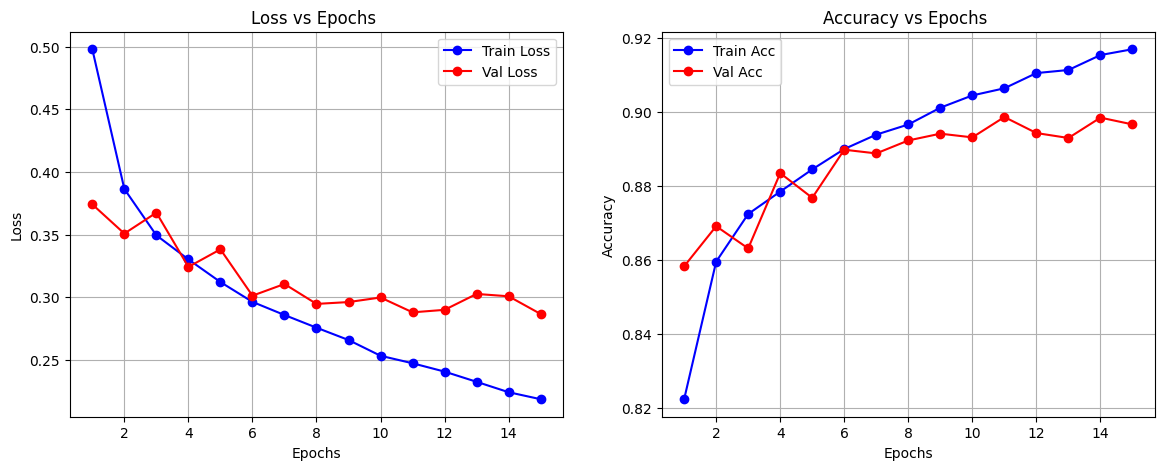


 Accuracy на тестовой выборке: 89.63%


In [45]:
train_loader, val_loader, test_loader = get_dataloaders(batch_size=64)

model_p1 = FlexibleMLP(activation_type='relu', use_dropout=True)

trainer_p1 = Trainer(model_p1, lr=0.001)

print("Начало обучения модели ReLU, Regularization")
trainer_p1.fit(train_loader, val_loader, epochs=15)

def plot_training_evolution(history, title_suffix=""):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'bo-', label='Train Loss')
    plt.plot(epochs, history['val_loss'], 'ro-', label='Val Loss')
    plt.title(f'Loss vs Epochs {title_suffix}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'bo-', label='Train Acc')
    plt.plot(epochs, history['val_acc'], 'ro-', label='Val Acc')
    plt.title(f'Accuracy vs Epochs {title_suffix}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.show()

plot_training_evolution(trainer_p1.history)

def evaluate_on_test(model, loader):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    accuracy = 100 * correct / total
    print(f'\n Accuracy на тестовой выборке: {accuracy:.2f}%')
    return accuracy

test_acc = evaluate_on_test(model_p1, test_loader)

## Пункт 2. Обучение модели без регуляризации

Начало обучения модели ReLU, No Regularization
Epoch 1/15 | Val Loss: 0.3951 | Val Acc: 0.8475
Epoch 2/15 | Val Loss: 0.3688 | Val Acc: 0.8653
Epoch 3/15 | Val Loss: 0.3635 | Val Acc: 0.8685
Epoch 4/15 | Val Loss: 0.3504 | Val Acc: 0.8782
Epoch 5/15 | Val Loss: 0.3406 | Val Acc: 0.8797
Epoch 6/15 | Val Loss: 0.3232 | Val Acc: 0.8853
Epoch 7/15 | Val Loss: 0.3212 | Val Acc: 0.8860
Epoch 8/15 | Val Loss: 0.3431 | Val Acc: 0.8813
Epoch 9/15 | Val Loss: 0.3398 | Val Acc: 0.8883
Epoch 10/15 | Val Loss: 0.3133 | Val Acc: 0.8932
Epoch 11/15 | Val Loss: 0.3429 | Val Acc: 0.8868
Epoch 12/15 | Val Loss: 0.3521 | Val Acc: 0.8912
Epoch 13/15 | Val Loss: 0.3592 | Val Acc: 0.8872
Epoch 14/15 | Val Loss: 0.3823 | Val Acc: 0.8857
Epoch 15/15 | Val Loss: 0.3619 | Val Acc: 0.8860


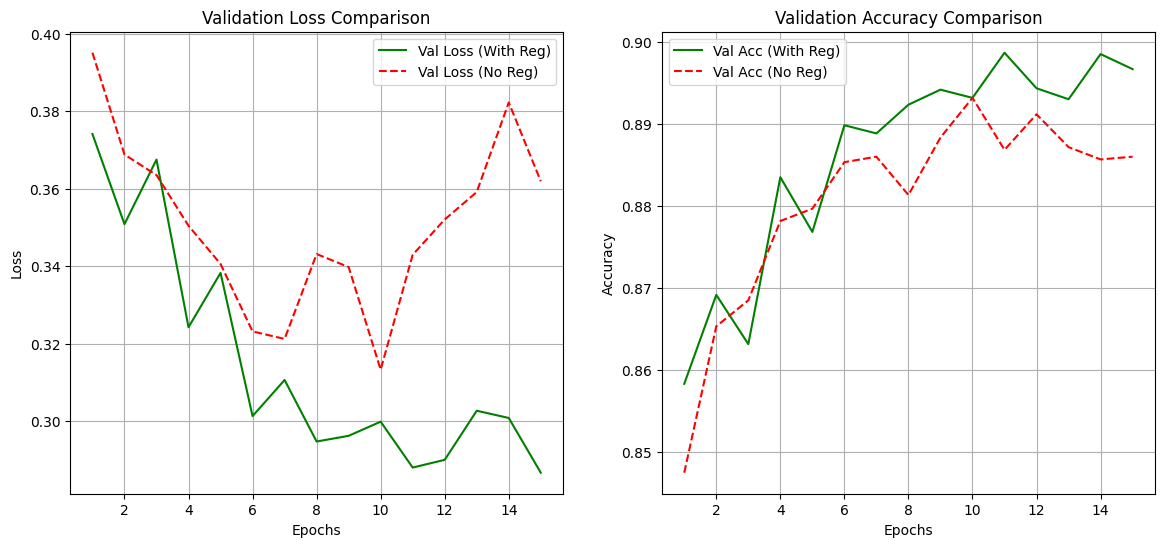


 Accuracy на тестовой выборке: 88.18%


In [46]:
model_p2 = FlexibleMLP(activation_type='relu', use_dropout=False)

trainer_p2 = Trainer(model_p2, lr=0.001)

print("Начало обучения модели ReLU, No Regularization")
trainer_p2.fit(train_loader, val_loader, epochs=15)

def compare_histories(h1, h2, label1="With Reg", label2="No Reg"):
    epochs = range(1, len(h1['train_loss']) + 1)
    
    plt.figure(figsize=(14, 6))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, h1['val_loss'], 'g-', label=f'Val Loss ({label1})')
    plt.plot(epochs, h2['val_loss'], 'r--', label=f'Val Loss ({label2})')
    plt.title('Validation Loss Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, h1['val_acc'], 'g-', label=f'Val Acc ({label1})')
    plt.plot(epochs, h2['val_acc'], 'r--', label=f'Val Acc ({label2})')
    plt.title('Validation Accuracy Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.show()

compare_histories(trainer_p1.history, trainer_p2.history)
test_acc_p2 = evaluate_on_test(model_p2, test_loader)

Без Dropout нейроны начинают слишком сильно полагаться на конкретные комбинации пикселей, которые встречаются только в тренировочном наборе. Поэтому после 10 эпохи ошибка начинает сильно расти. Модель запомнила конкретные комбинации и на новых данных начинает плохо работать. То есть, она начала сильно переобучаться.

Удалив Batch Normalization, можно заметить, что градиенты стали менее стабильными, и кривая обучения может выглядеть более дерганой

## Пункт 3. Функция активации - sigmoid

Начало обучения модели Sigmoid, Regularization
Epoch 1/15 | Val Loss: 0.4556 | Val Acc: 0.8352
Epoch 2/15 | Val Loss: 0.4189 | Val Acc: 0.8487
Epoch 3/15 | Val Loss: 0.4017 | Val Acc: 0.8533
Epoch 4/15 | Val Loss: 0.3880 | Val Acc: 0.8618
Epoch 5/15 | Val Loss: 0.3781 | Val Acc: 0.8590
Epoch 6/15 | Val Loss: 0.3585 | Val Acc: 0.8743
Epoch 7/15 | Val Loss: 0.3595 | Val Acc: 0.8677
Epoch 8/15 | Val Loss: 0.3454 | Val Acc: 0.8713
Epoch 9/15 | Val Loss: 0.3361 | Val Acc: 0.8782
Epoch 10/15 | Val Loss: 0.3486 | Val Acc: 0.8702
Epoch 11/15 | Val Loss: 0.3406 | Val Acc: 0.8767
Epoch 12/15 | Val Loss: 0.3216 | Val Acc: 0.8830
Epoch 13/15 | Val Loss: 0.3305 | Val Acc: 0.8805
Epoch 14/15 | Val Loss: 0.3158 | Val Acc: 0.8848
Epoch 15/15 | Val Loss: 0.3174 | Val Acc: 0.8860


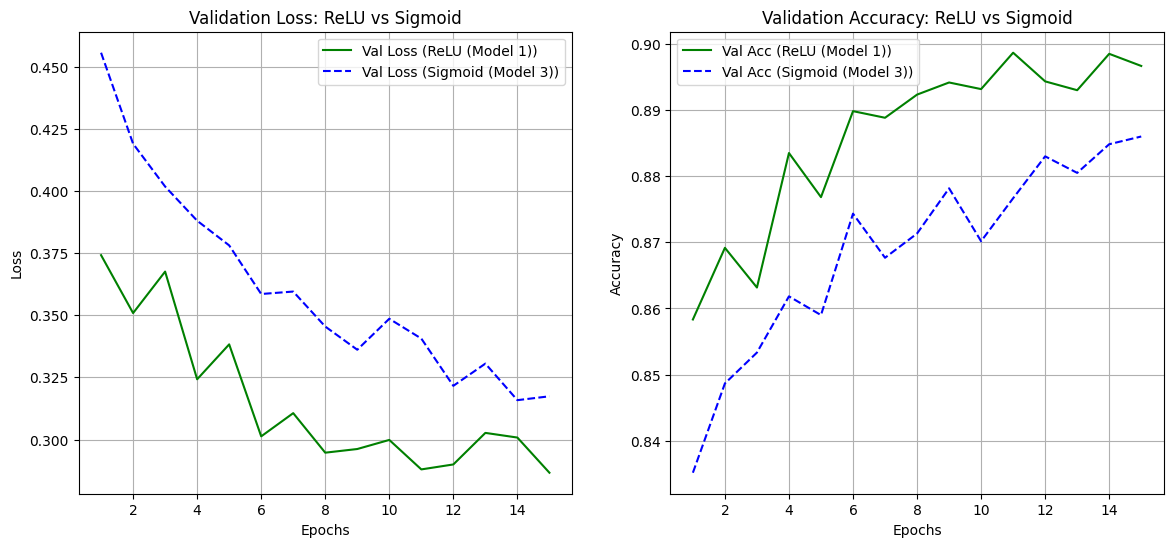


 Accuracy на тестовой выборке: 87.85%


In [48]:
model_p3 = FlexibleMLP(activation_type='sigmoid', use_dropout=True)

trainer_p3 = Trainer(model_p3, lr=0.001)

print("Начало обучения модели Sigmoid, Regularization")
trainer_p3.fit(train_loader, val_loader, epochs=15)

def compare_activations(h_relu, h_sig, label1="ReLU (Model 1)", label2="Sigmoid (Model 3)"):
    epochs = range(1, len(h_relu['train_loss']) + 1)
    
    plt.figure(figsize=(14, 6))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, h_relu['val_loss'], 'g-', label=f'Val Loss ({label1})')
    plt.plot(epochs, h_sig['val_loss'], 'b--', label=f'Val Loss ({label2})')
    plt.title('Validation Loss: ReLU vs Sigmoid')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, h_relu['val_acc'], 'g-', label=f'Val Acc ({label1})')
    plt.plot(epochs, h_sig['val_acc'], 'b--', label=f'Val Acc ({label2})')
    plt.title('Validation Accuracy: ReLU vs Sigmoid')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.show()

compare_activations(trainer_p1.history, trainer_p3.history)
test_acc_p3 = evaluate_on_test(model_p3, test_loader)

Результат ухудшился:
- Точность стала меньше
- Потеря стала больше

Почему:<br>
 Это произошло из за того, что сигмоида насыщается при слишком больших или слишком маленьких по модулю значениях входа, из-за чего её производная становится очень маленькой. Это приводит к затуханию градиента и замедляет обучение нейронной сети. Сигнал об ошибке, доходя до первых слоев сети, становится ничтожно малым. Веса практически не обновляются, и сеть не учится выделять базовые признаки из пикселей.

## Пункт 4. Модель CNN

Начало обучения CNN...
Epoch 1/10 | Val Loss: 0.3337 | Val Acc: 0.8853
Epoch 2/10 | Val Loss: 0.2951 | Val Acc: 0.8952
Epoch 3/10 | Val Loss: 0.2573 | Val Acc: 0.9052
Epoch 4/10 | Val Loss: 0.2741 | Val Acc: 0.9030
Epoch 5/10 | Val Loss: 0.2410 | Val Acc: 0.9125
Epoch 6/10 | Val Loss: 0.2399 | Val Acc: 0.9140
Epoch 7/10 | Val Loss: 0.2481 | Val Acc: 0.9117
Epoch 8/10 | Val Loss: 0.2430 | Val Acc: 0.9123
Epoch 9/10 | Val Loss: 0.2444 | Val Acc: 0.9150
Epoch 10/10 | Val Loss: 0.2418 | Val Acc: 0.9180

Результаты сверточной нейросети (CNN):

 Accuracy на тестовой выборке: 91.30%


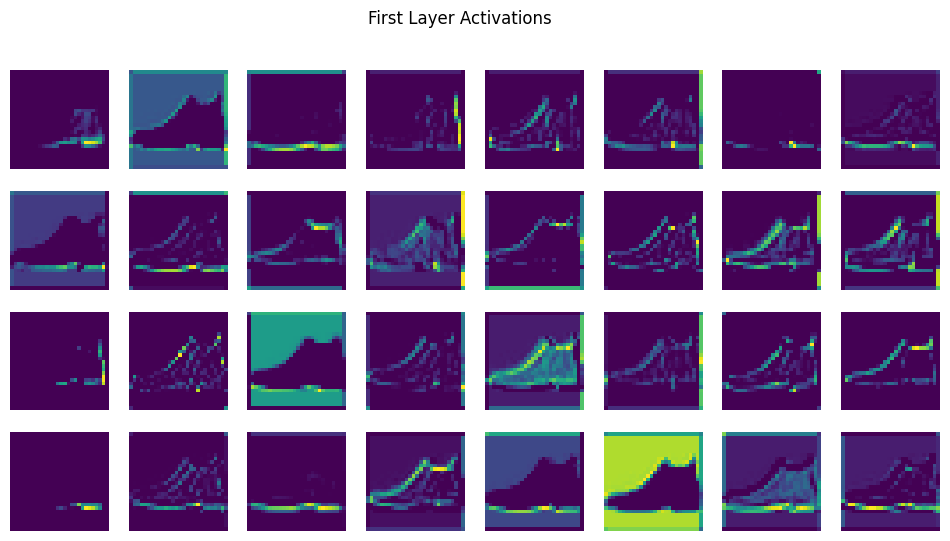

In [49]:
model_cnn = SimpleCNN()

trainer_cnn = Trainer(model_cnn, lr=0.001)

print("Начало обучения CNN...")
trainer_cnn.fit(train_loader, val_loader, epochs=10)

print("\nРезультаты сверточной нейросети (CNN):")
test_acc_cnn = evaluate_on_test(model_cnn, test_loader)

visualize_activations(model_cnn, test_loader)

На первых слоях модель выделяет границы. Можно увидеть четкие контуры подошвы ботинок, их форму или текстуру материала.